# Assignment 2 - Comparing genotype files


In [10]:
pip install numpy scipy matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import glob
import itertools
from collections import Counter
from typing import Dict, Tuple, List, Set

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

valid_nts = set("ACGT")
autosomal_chr = {str(i) for i in range(1, 23)}

def normalize_chrom(c: str) -> str:
    c = c.strip()
    c = c[3:] if c.lower().startswith("chr") else c
    return c

def parse_file(path: str) -> Dict[str, Tuple[str, str]]:
    d: Dict[str, Tuple[str, str]] = {}
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if not line or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 4:
                continue
            rsid, chrom, pos, gt = parts[0].strip(), parts[1].strip(), parts[2], parts[3].strip()

            if not rsid.startswith("rs"):
                continue

            chrom = normalize_chrom(chrom)
            if chrom not in autosomal_chr:
                continue

            d[rsid] = (chrom, gt)
    return d

def called(gt: str) -> bool:
    if gt is None:
        return False
    gt = gt.strip().upper()
    return len(gt) == 2 and gt[0] in valid_nts and gt[1] in valid_nts

def ibs(gt1: str, gt2: str) -> int:
    return sum((Counter(gt1) & Counter(gt2)).values())

def create_label(filename: str) -> str:
    base = filename.split("/")[-1]
    return base.split("DNA23andMe")[0].rstrip("_")


In [ ]:
# 1) Read all files
files = sorted(glob.glob("*DNA23andMe*"))
if not files:
    raise SystemExit("No files matched *DNA23andMe* in the current directory.")

labels = [create_label(f) for f in files]
print(f"Found {len(files)} files:")
for f in files:
    print("  ", f)

data = {}
for f in files:
    print(f"Loading {f} ...")
    data[f] = parse_file(f)

# 2) IBS similarity matrix (0..1) with diagonal
n = len(files)
S = np.zeros((n, n), dtype=float)
pair_used = np.zeros((n, n), dtype=int)

for i in range(n):
    d = data[files[i]]
    sum_ibs = 0
    n_used = 0
    for rsid, (chrom, gt) in d.items():
        if not called(gt):
            continue
        sum_ibs += ibs(gt, gt)
        n_used += 1
    sim = (sum_ibs / (2.0 * n_used)) if n_used > 0 else 0.0
    S[i, i] = sim
    pair_used[i, i] = n_used
    print(f"{labels[i]} vs self: used {n_used:,} SNPs, IBS sim {sim:.6f}")

for i, j in itertools.combinations(range(n), 2):
    d1, d2 = data[files[i]], data[files[j]]
    sum_ibs = 0
    n_used = 0

    for rsid in (d1.keys() & d2.keys()):
        gt1 = d1[rsid][1]; gt2 = d2[rsid][1]
        if not (called(gt1) and called(gt2)):
            continue
        sum_ibs += ibs(gt1, gt2)
        n_used += 1

    sim = (sum_ibs / (2.0 * n_used)) if n_used > 0 else 0.0
    S[i, j] = S[j, i] = sim
    pair_used[i, j] = pair_used[j, i] = n_used
    print(f"{labels[i]} vs {labels[j]}: used {n_used:,} SNPs, IBS sim {sim:.6f}")

# 3) Write similarity matrix TSV
out_tsv = "ibs_similarity_matrix.tsv"
with open(out_tsv, "w", encoding="utf-8") as out:
    out.write("sample\t" + "\t".join(labels) + "\n")
    for i in range(n):
        row = [labels[i]] + [f"{S[i, j]:.6f}" for j in range(n)]
        out.write("\t".join(row) + "\n")
print(f"Wrote: {out_tsv}")
S


Found 7 files:
   Cristelle_ChirwaDNA23andMe_v5_Full_20180208094401.txt
   Kate_SheridanDNA23andMe_v5_Full_20180523150056.txt
   Lisa_FaumanDNA23andMe_v5_Full_20180326062517.txt
   Oliver_MoadelDNA23andMe_v5_Full_20180130222634.txt
   Rachel_KarchinDNA23andMe_v4_Full_20241229220425.txt
   Steve_SalzbergDNA23andMe_v3.txt
   Terion_MillerDNA23andMe_v4_Full_20180506195602.txt
Loading Cristelle_ChirwaDNA23andMe_v5_Full_20180208094401.txt ...
Loading Kate_SheridanDNA23andMe_v5_Full_20180523150056.txt ...
Loading Lisa_FaumanDNA23andMe_v5_Full_20180326062517.txt ...
Loading Oliver_MoadelDNA23andMe_v5_Full_20180130222634.txt ...
Loading Rachel_KarchinDNA23andMe_v4_Full_20241229220425.txt ...
Loading Steve_SalzbergDNA23andMe_v3.txt ...
Loading Terion_MillerDNA23andMe_v4_Full_20180506195602.txt ...
Cristelle_Chirwa vs self: used 589,337 SNPs, IBS sim 1.000000
Kate_Sheridan vs self: used 585,111 SNPs, IBS sim 1.000000
Lisa_Fauman vs self: used 588,585 SNPs, IBS sim 1.000000
Oliver_Moadel vs self:

array([[1.        , 0.85862257, 0.85678151, 0.85594861, 0.74196628,
        0.72940349, 0.74695986],
       [0.85862257, 1.        , 0.85800615, 0.85683089, 0.74140478,
        0.73040273, 0.74804069],
       [0.85678151, 0.85800615, 1.        , 0.857288  , 0.74416055,
        0.7327255 , 0.74415186],
       [0.85594861, 0.85683089, 0.857288  , 1.        , 0.74347662,
        0.73024799, 0.74179068],
       [0.74196628, 0.74140478, 0.74416055, 0.74347662, 1.        ,
        0.74401415, 0.75001988],
       [0.72940349, 0.73040273, 0.7327255 , 0.73024799, 0.74401415,
        1.        , 0.74005097],
       [0.74695986, 0.74804069, 0.74415186, 0.74179068, 0.75001988,
        0.74005097, 1.        ]])

In [ ]:
# 4) Hierarchical clustering with Ward on distance = 1 - similarity
D = 1.0 - S
np.fill_diagonal(D, 0.0)
condensed = squareform(D, checks=False)
Z = linkage(condensed, method="ward")
Z[:]


array([[ 0.        ,  1.        ,  0.14137743,  2.        ],
       [ 2.        ,  3.        ,  0.142712  ,  2.        ],
       [ 7.        ,  8.        ,  0.14416604,  4.        ],
       [ 4.        ,  6.        ,  0.24998012,  2.        ],
       [ 5.        , 10.        ,  0.26058552,  3.        ],
       [ 9.        , 11.        ,  0.36330392,  7.        ]])

In [ ]:
# 5) Compute mean similarity
def build_cluster_memberships(Z: np.ndarray, n_leaves: int) -> List[Set[int]]:
    members: List[Set[int]] = [set([i]) for i in range(n_leaves)]
    for row_idx, (a, b, dist, cnt) in enumerate(Z):
        a = int(a); b = int(b)
        new = members[a] | members[b]
        members.append(new)
    return members

members = build_cluster_memberships(Z, n)
merge_sims = []
for k in range(n - 1):
    a = int(Z[k, 0]); b = int(Z[k, 1])
    A = members[a]; B = members[b]
    vals = [S[i, j] for i in A for j in B]
    merge_sims.append(float(np.mean(vals)) if vals else float("nan"))
merge_sims[:5], len(merge_sims)


([0.8586225653113203,
  0.8572880029258655,
  0.856891789969076,
  0.7500198839534602,
  0.7420325622969689],
 6)

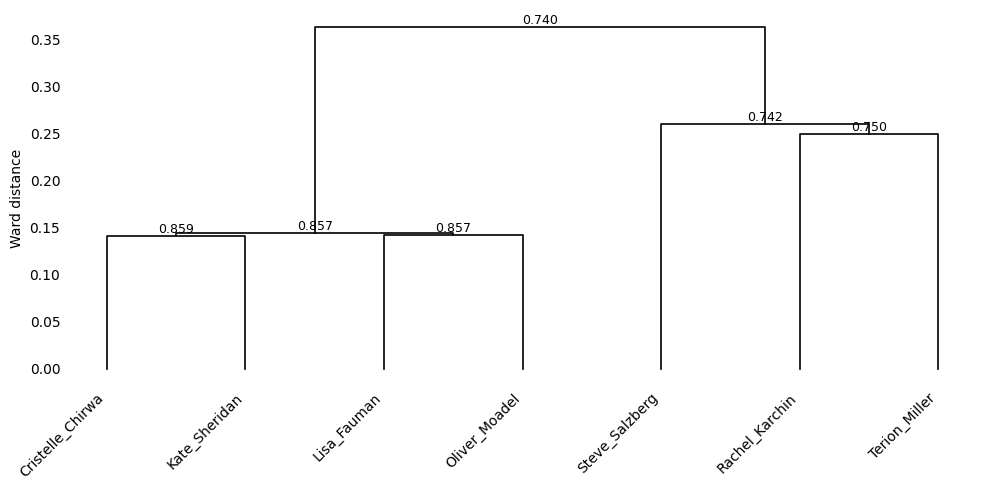

In [15]:
# 6) Plot dendrogram
ddata = dendrogram(Z, labels=labels, no_plot=True,)
fig, ax = plt.subplots(figsize=(10, 5))

for xs, ys in zip(ddata["icoord"], ddata["dcoord"]):
    ax.plot(xs, ys, color="black", linewidth=1.2)
    
for k, (xs, ys) in enumerate(zip(ddata["icoord"], ddata["dcoord"])):
    x_mid = 0.5 * (xs[1] + xs[2])
    y_top = ys[1]
    sim = merge_sims[k]
    if np.isfinite(sim):
        ax.text(
            x_mid, y_top, f"{sim:.3f}", ha="center", va="bottom", fontsize=9, color="black",
        )

ax.set_xticks([5 + 10*i for i in range(len(ddata["ivl"]))])
ax.set_xticklabels(ddata["ivl"], rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Ward distance")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)
plt.tight_layout()
plt.show()
